With random restarts, the same as ../3_1_pymc.ipynb

In [4]:
import numpy as np
import pymc as pm
import pytensor
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
pytensor.config.cxx = '/usr/bin/clang++'

In [7]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
max_iters = 100_000

def run_model(n_mc_samples = 1, optimizer = "default", seed=0):
    with pm.Model() as single_model:
        # Define priors and likelihood
        mu = pm.Normal("mu", mu_prior, sigma_prior)
        likelihood = pm.Normal('y', mu=mu, sigma=sigma_like, observed=np.array([]))
        
        advi = pm.ADVI(random_seed=seed)

        tracker = pm.callbacks.Tracker(
                mean = advi.approx.mean.eval,
                std = advi.approx.std.eval
            )
            
        if optimizer == 'default':
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples,
            )
        elif optimizer == 'adam':
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples,
                obj_optimizer=pm.adam()
            )
    return tracker['mean'], tracker['std']

def run_restart(seed):
    np.random.seed(seed)
    single_mus_unc, single_stds_unc = run_model(seed=seed)
    multi_mus_unc, multi_stds_unc = run_model(n_mc_samples=100, seed=seed+1000)
    adam_single_mus_unc, adam_single_stds_unc = run_model(optimizer='adam', seed=seed)
    adam_multi_mus_unc, adam_multi_stds_unc = run_model(n_mc_samples=100, optimizer='adam', seed=seed+1000)
    return (single_mus_unc, single_stds_unc), (multi_mus_unc, multi_stds_unc), (adam_single_mus_unc, adam_single_stds_unc), (adam_multi_mus_unc, adam_multi_stds_unc)

In [ ]:
results = []
adam_results = []
for seed in tqdm(range(50)):
    result = run_restart(seed)
    results.append(result[:2])
    adam_results.append(result[2:])

  0%|          | 0/50 [00:00<?, ?it/s]

Finished [100%]: Average Loss = -0.00016682
Finished [100%]: Average Loss = 1.0022e-05
Finished [100%]: Average Loss = -2.5951e-05
Finished [100%]: Average Loss = 1.0643e-05
Finished [100%]: Average Loss = 0.0019293
Finished [100%]: Average Loss = 1.0193e-05
Finished [100%]: Average Loss = 3.8597e-05
Finished [100%]: Average Loss = 6.9895e-06
Finished [100%]: Average Loss = 0.00095141
Finished [100%]: Average Loss = 1.5699e-06
Finished [100%]: Average Loss = 0.00028788
Finished [100%]: Average Loss = 6.2637e-06
Finished [100%]: Average Loss = 0.0022211
Finished [100%]: Average Loss = -1.0218e-05
Finished [100%]: Average Loss = 0.001055
Finished [100%]: Average Loss = 4.0222e-06
Finished [100%]: Average Loss = -0.00018448
Finished [100%]: Average Loss = 3.6602e-06
Finished [100%]: Average Loss = 8.1505e-05
Finished [100%]: Average Loss = 9.4976e-06
Finished [100%]: Average Loss = 0.00094456
Finished [100%]: Average Loss = 1.8411e-05
Finished [100%]: Average Loss = 8.3545e-05
Finished [1

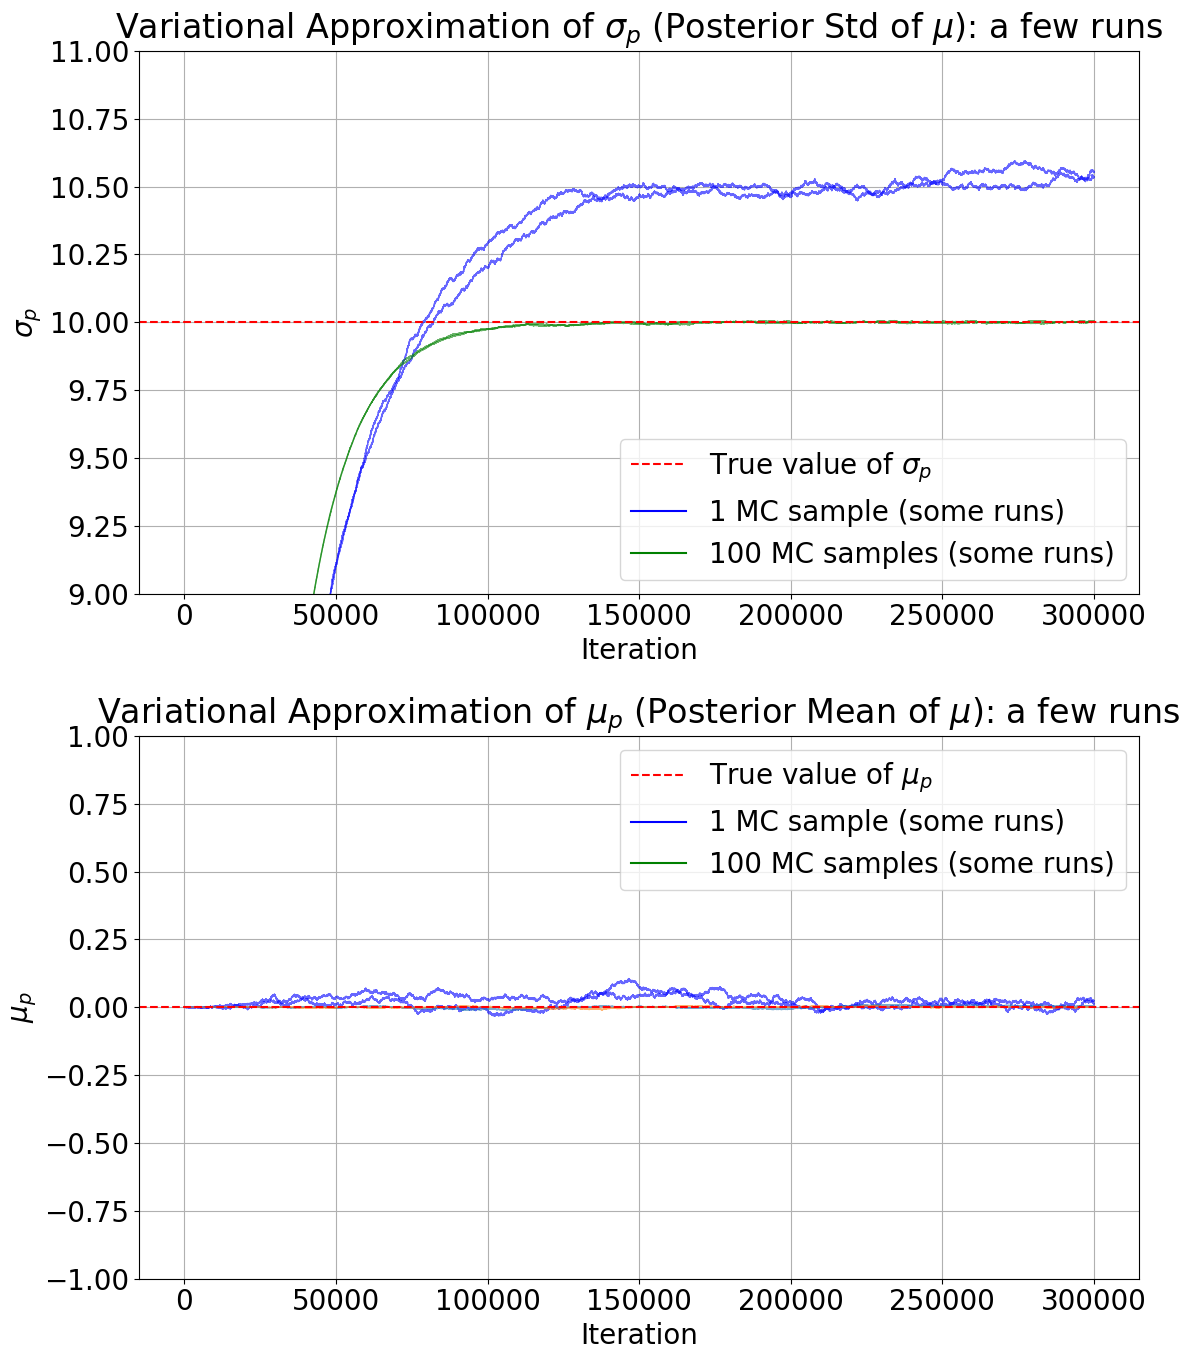

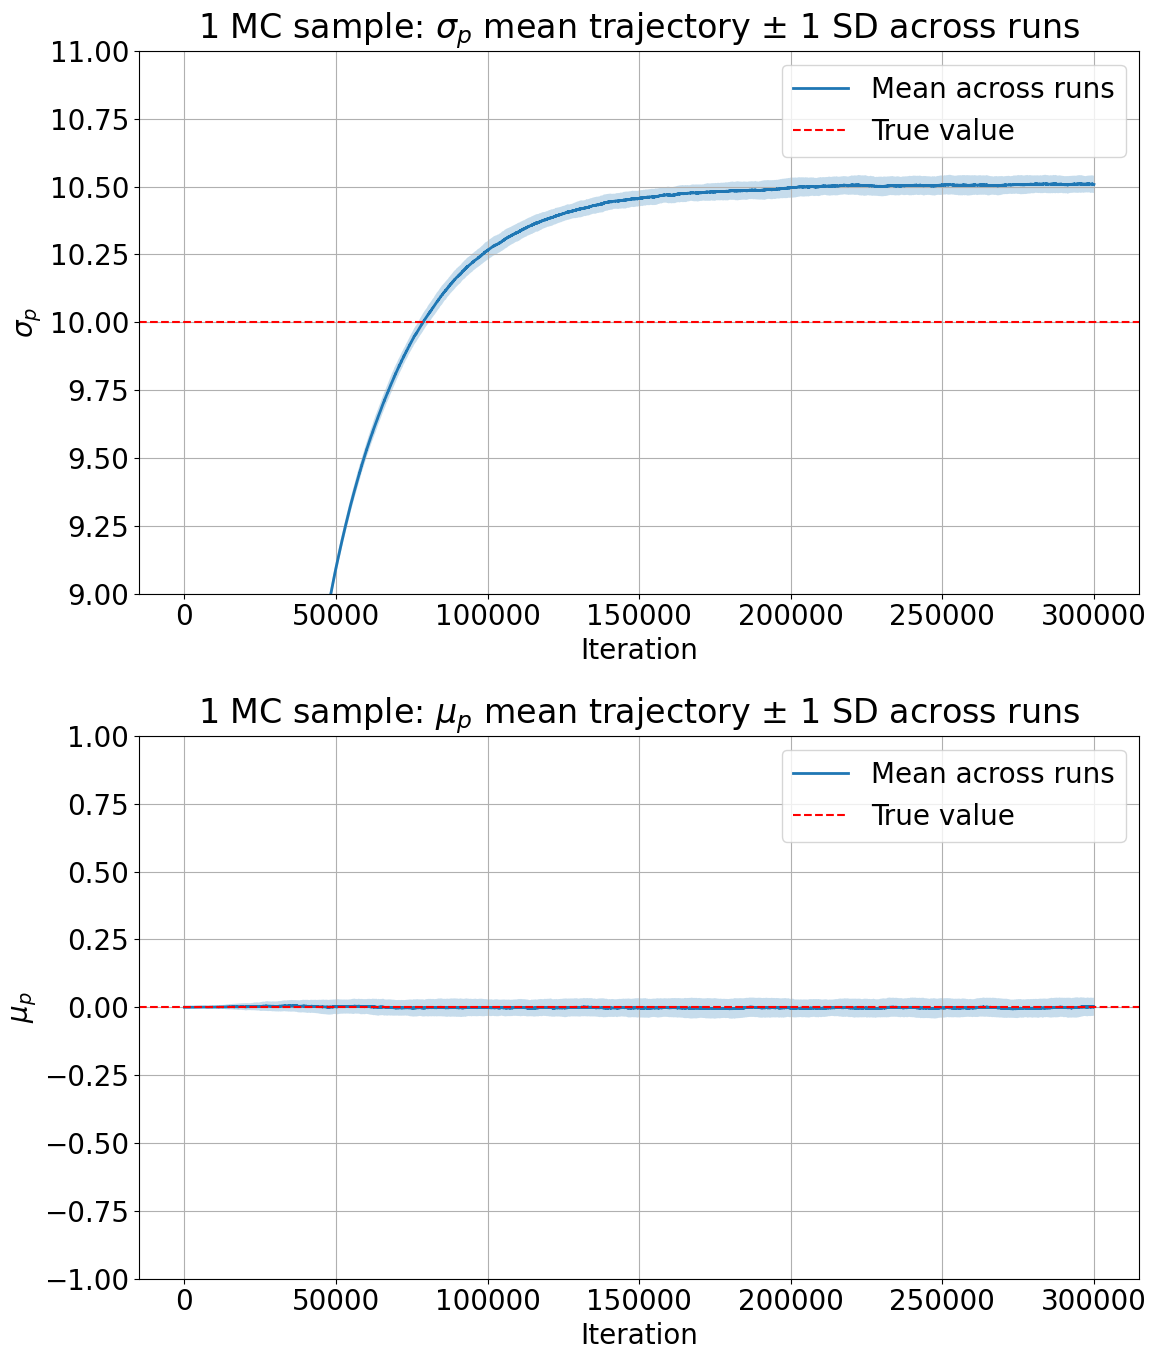

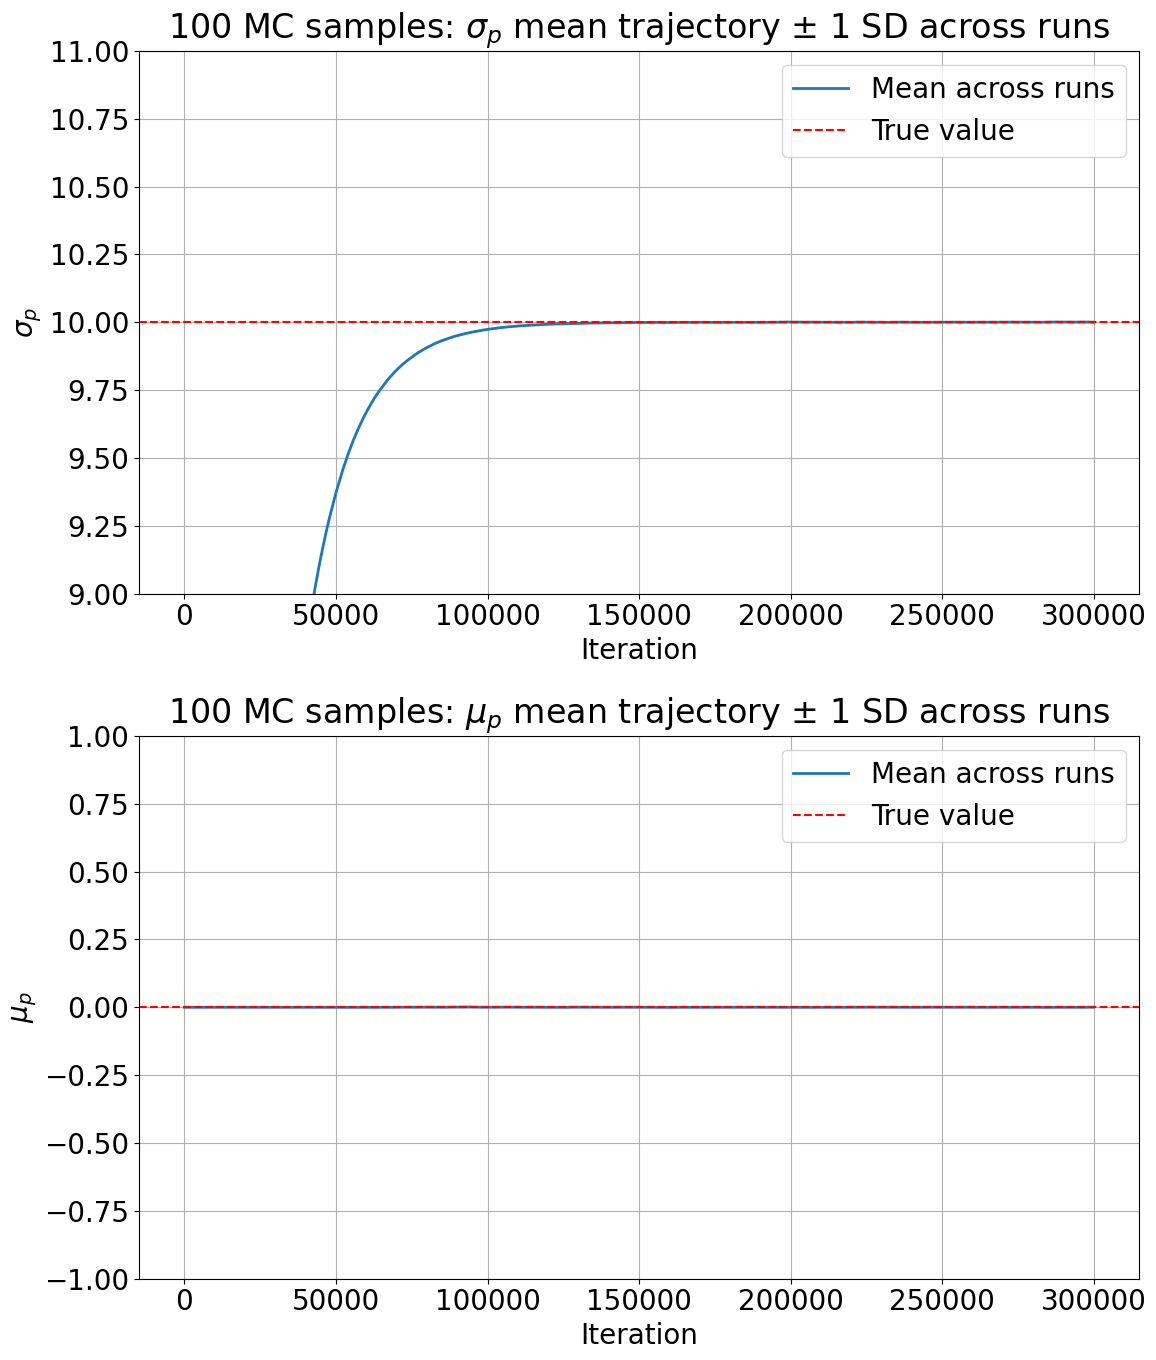

In [ ]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_tracker, multi_tracker in results:
    single_means.append(single_tracker['mean'])
    single_stds.append(single_tracker['std'])
    multi_means.append(multi_tracker['mean'])
    multi_stds.append(multi_tracker['std'])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T, _ = single_means.shape
single_means = single_means.reshape(N, T)
single_stds  = single_stds.reshape(N, T)
multi_means  = multi_means.reshape(N, T)
multi_stds   = multi_stds.reshape(N, T)
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(sigma_prior, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(mu_prior, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, sigma_prior,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, single_means, mu_prior,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, sigma_prior,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, multi_means, mu_prior,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()

# Adam results

In [ ]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks
# ----------------------------
adam_single_means, adam_single_stds = [], []
adam_multi_means,  adam_multi_stds  = [], []

for single_tracker, multi_tracker in adam_results:
    adam_single_means.append(single_tracker['mean'])
    adam_single_stds.append(single_tracker['std'])
    adam_multi_means.append(multi_tracker['mean'])
    adam_multi_stds.append(multi_tracker['std'])

adam_single_means = np.stack(adam_single_means, axis=0)  # (N, T)
adam_single_stds  = np.stack(adam_single_stds,  axis=0)  # (N, T)
adam_multi_means  = np.stack(adam_multi_means,  axis=0)  # (N, T)
adam_multi_stds   = np.stack(adam_multi_stds,   axis=0)  # (N, T)

N, T, _ = adam_single_means.shape
adam_single_means = adam_single_means.reshape(N, T)
adam_single_stds  = adam_single_stds.reshape(N, T)
adam_multi_means  = adam_multi_means.reshape(N, T)
adam_multi_stds   = adam_multi_stds.reshape(N, T)
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, adam_single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, adam_multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(sigma_prior, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

# mean of mu
for i in idx:
    axs[1].plot(x, adam_single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, adam_multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(mu_prior, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, adam_single_stds, sigma_prior,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, adam_single_means, mu_prior,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, adam_multi_stds, sigma_prior,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, adam_multi_means, mu_prior,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()